# 01 · Exploratory Data Analysis - Dubai hourly water demand

**Goal:** understand the demand signal and its drivers well enough to design a **day-ahead, hourly** forecast
(24 values for tomorrow, issued every morning) and to justify every modelling choice that follows in
`02_modelling.ipynb`.

| | |
|---|---|
| **Target** | `demand_m3h` - city-wide hourly water demand (m³/h), site `DXB-CITY-TOTAL` |
| **Drivers** | observed weather, the day-ahead weather forecast, public holidays, Ramadan, school breaks, events |
| **Period** | 2024-01-01 → 2026-09-30, hourly, Dubai local time (UTC+4, no daylight saving) |
| **Source** | `mlops_dev.bronze.*` - the raw source-system extracts the production pipeline ingests |

**How to read this notebook.** Every section ends with a short **Findings** box - what the data shows, with the
number that supports it. **Section 15** consolidates all findings into modelling decisions and review points.

> **Run it:** on Databricks (a Spark session is used automatically), or locally - the first run pulls the four
> source tables through a SQL warehouse (`DATABRICKS_CONFIG_PROFILE`, optional `DATABRICKS_WAREHOUSE_ID`)
> and caches them under `data/cache/`; later runs are offline.

## 0. Setup

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import MSTL, STL
from statsmodels.tsa.stattools import acf, adfuller, kpss

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from water_forecasting.config import ProjectConfig  # noqa: E402
from water_forecasting.exploration import load_source  # noqa: E402

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (14, 4.5), "axes.titleweight": "bold",
                     "axes.titlesize": 12, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 40, "display.width", 200)
DOW = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

In [2]:
cfg = ProjectConfig.from_yaml(ROOT / "project_config.yml", env="prod")
try:
    spark  # noqa: B018 - defined on Databricks
except NameError:
    spark = None

raw = load_source(cfg, spark=spark, cache_dir=ROOT / "data" / "cache")
cons, wx, fc, cal = raw["consumption"], raw["weather_obs"], raw["weather_fcst"], raw["calendar"]
print("Loaded:", {k: v.shape for k, v in raw.items()})

Loaded: {'consumption': (24096, 6), 'weather_obs': (24096, 10), 'weather_fcst': (24096, 6), 'calendar': (1004, 11)}


## 1. Data overview

What each source contains, its time coverage, and whether the hourly grid is regular. A regular grid (no missing
or duplicated timestamps) is a precondition for lag features and seasonal decomposition.

In [3]:
def coverage(df, ts, name, freq):
    t = df[ts]
    expected = len(pd.date_range(t.min(), t.max(), freq=freq))
    return {"table": name, "rows": len(df), "columns": df.shape[1], "start": t.min(), "end": t.max(),
            "expected_rows": expected, "missing_timestamps": expected - t.nunique(),
            "duplicate_timestamps": int(t.duplicated().sum())}

overview = pd.DataFrame([
    coverage(cons, "timestamp_local", "demand (SCADA)", "h"),
    coverage(wx, "timestamp_local", "weather observed", "h"),
    coverage(fc, "timestamp_local", "weather forecast (by target hour)", "h"),
    coverage(cal, "date", "calendar", "D"),
])
overview

,table,rows,columns,start,end,expected_rows,missing_timestamps,duplicate_timestamps
0,demand (SCADA),24096,6,2024-01-01,2026-09-30 23:00:00,24096,0,0
1,weather observed,24096,10,2024-01-01,2026-09-30 23:00:00,24096,0,0
2,weather forecast (by target hour),24096,6,2024-01-01,2026-09-30 23:00:00,24096,0,0
3,calendar,1004,11,2024-01-01,2026-09-30 00:00:00,1004,0,0


In [4]:
display(cons.head(3))
display(wx.head(3))
display(fc.head(3))
display(cal[cal.holiday_name.notna() | cal.event_name.notna()].head(3))

,timestamp_local,timestamp_utc,site_id,demand_m3h,source_system,quality_note
0,2024-01-01 00:00:00,2023-12-31 20:00:00,DXB-CITY-TOTAL,80156.8,SCADA-HIST,None
1,2024-01-01 01:00:00,2023-12-31 21:00:00,DXB-CITY-TOTAL,76550.7,SCADA-HIST,None
2,2024-01-01 02:00:00,2023-12-31 22:00:00,DXB-CITY-TOTAL,70969.9,SCADA-HIST,None


,location,timestamp_local,timestamp_utc,temperature_c,apparent_temperature_c,relative_humidity_pct,precipitation_mm,wind_speed_kmh,solar_radiation_wm2,weather_source
0,"Dubai (25.2048N, 55.2708E)",2024-01-01 00:00:00,2023-12-31 20:00:00,20.16,17.78,64.3,0.0,17.3,0.0,simulated_climatology_dubai
1,"Dubai (25.2048N, 55.2708E)",2024-01-01 01:00:00,2023-12-31 21:00:00,20.58,17.97,60.7,0.0,17.8,0.0,simulated_climatology_dubai
2,"Dubai (25.2048N, 55.2708E)",2024-01-01 02:00:00,2023-12-31 22:00:00,19.34,15.68,63.1,0.0,22.2,0.0,simulated_climatology_dubai


,forecast_issued_local,timestamp_local,forecast_temperature_c,forecast_relative_humidity_pct,forecast_precipitation_mm,forecast_source
0,2023-12-31 06:00:00,2024-01-01 00:00:00,20.16,63.7,0.0,simulated_day_ahead_nwp
1,2023-12-31 06:00:00,2024-01-01 01:00:00,19.64,59.5,0.0,simulated_day_ahead_nwp
2,2023-12-31 06:00:00,2024-01-01 02:00:00,18.23,66.5,0.0,simulated_day_ahead_nwp


,date,holiday_name,is_public_holiday,day_of_week,is_weekend,is_ramadan,ramadan_day,is_school_break,event_name,event_type,event_note
0,2024-01-01,New Year's Day,True,Monday,False,False,0,False,None,None,None
98,2024-04-08,Eid al-Fitr holiday,True,Monday,False,True,29,False,None,None,None
99,2024-04-09,Eid al-Fitr holiday,True,Tuesday,False,True,30,False,None,None,None


In [5]:
offset = (cons.timestamp_local - cons.timestamp_utc).dt.total_seconds().div(3600).value_counts()
lead = (fc.timestamp_local - fc.forecast_issued_local).dt.total_seconds().div(3600)
print("local - UTC offset (hours):", offset.to_dict())
print("sites:", cons.site_id.unique(), "| weather location:", wx.location.unique())
print("forecast vintages per target hour:", fc.groupby("timestamp_local").size().max(),
      "| issue hour(s):", sorted(fc.forecast_issued_local.dt.hour.unique()),
      f"| lead time {lead.min():.0f}-{lead.max():.0f} h")

local - UTC offset (hours): {4.0: 24096}
sites: ['DXB-CITY-TOTAL'] | weather location: ['Dubai (25.2048N, 55.2708E)']
forecast vintages per target hour: 1 | issue hour(s): [np.int32(6)] | lead time 18-41 h


> **Findings - data overview**
> * All four sources are complete on their grid: **24,096 hourly rows with no missing and no duplicated
>   timestamps**, and 1,004 calendar days. Gaps exist only as *null values*, not as missing rows (Section 2).
> * Time is **Dubai local, a constant UTC+4** - no daylight-saving shifts to handle.
> * **One site** (`DXB-CITY-TOTAL`) and one weather location: a single city-wide series.
> * The weather forecast has **exactly one vintage per target hour**, issued **06:00 local the previous day**,
>   with 18-41 h lead time. That is precisely the forecast available when tomorrow's demand forecast is issued.

## 2. Data-quality audit

The SCADA feed carries its own `quality_note`. We check every flagged category, look for problems the feed did
**not** flag, and verify which ones the production quality gate (`src/water_forecasting/quality.py`) would catch.

In [6]:
notes = cons.quality_note.fillna("ok").value_counts().rename("rows").to_frame()
notes["pct"] = (notes.rows / len(cons) * 100).round(3)
notes["demand_min"] = cons.groupby(cons.quality_note.fillna("ok")).demand_m3h.min()
notes["demand_max"] = cons.groupby(cons.quality_note.fillna("ok")).demand_m3h.max()
notes

,rows,pct,demand_min,demand_max
quality_note,,,,
ok,24020,99.685,44869.0,175428.3
telemetry_gap,60,0.249,NaN,NaN
frozen_value,9,0.037,79737.3,79737.3
spike,6,0.025,217984.9,352075.5
impossible_value,1,0.004,-1.0,-1.0


In [7]:
y_raw = cons.set_index("timestamp_local").demand_m3h

# Generic stuck-meter detector: >= 3 consecutive identical readings
same = y_raw.diff().eq(0)
run_id = (same != same.shift()).cumsum()
frozen = same & same.groupby(run_id).transform("sum").ge(2)
frozen = frozen | frozen.shift(-1, fill_value=False)

q = cfg.quality
gate = pd.DataFrame({
    "null_value": y_raw.isna(),
    "out_of_range": (y_raw < q.demand_min_m3h) | (y_raw > q.demand_max_m3h),
    "frozen_run": frozen,
})
note = cons.set_index("timestamp_local").quality_note.fillna("ok")
coverage_tbl = gate.groupby(note).sum().astype(int)
coverage_tbl["rows"] = note.value_counts()
coverage_tbl["caught_by_production_gate"] = (gate[["null_value", "out_of_range"]].any(axis=1)
                                             .groupby(note).sum().astype(int))
coverage_tbl

,null_value,out_of_range,frozen_run,rows,caught_by_production_gate
quality_note,,,,,
frozen_value,0,0,9,9,0
impossible_value,0,1,0,1,1
ok,0,0,0,24020,0
spike,0,6,0,6,6
telemetry_gap,60,0,0,60,60


telemetry-gap run lengths (hours -> count): {1: 1, 2: 2, 3: 1, 4: 2, 5: 4, 6: 4}
frozen value runs: {79737.3: 9}


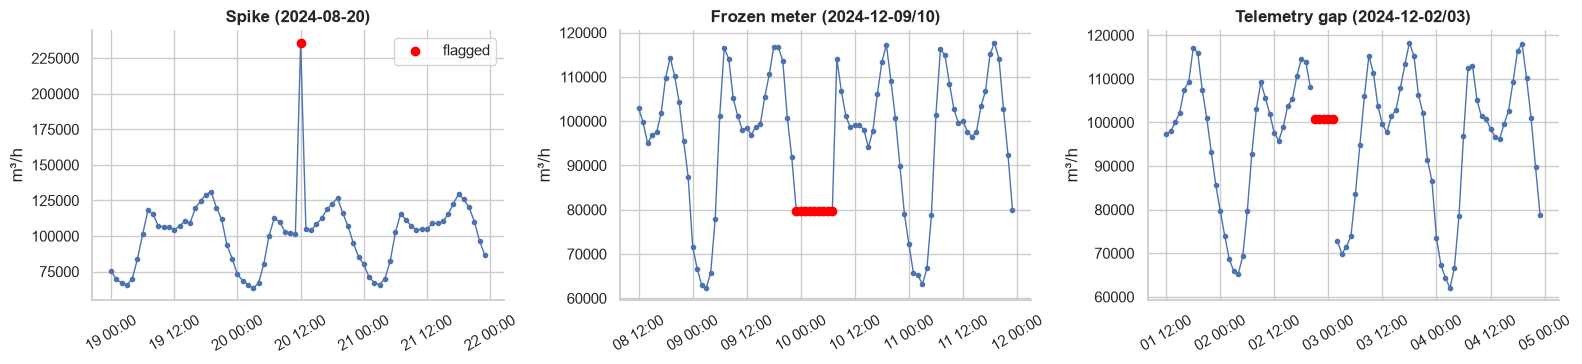

In [8]:
gaps = y_raw.isna()
gap_len = gaps.groupby((gaps != gaps.shift()).cumsum()).sum()
print("telemetry-gap run lengths (hours -> count):", gap_len[gap_len > 0].value_counts().sort_index().to_dict())
print("frozen value runs:", y_raw[frozen].groupby(y_raw[frozen]).size().to_dict())

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, (title, start, end) in zip(axes, [("Spike (2024-08-20)", "2024-08-19", "2024-08-21"),
                                            ("Frozen meter (2024-12-09/10)", "2024-12-08 12:00", "2024-12-11"),
                                            ("Telemetry gap (2024-12-02/03)", "2024-12-01 12:00", "2024-12-04")]):
    seg = y_raw[start:end]
    ax.plot(seg.index, seg.values, marker=".", lw=1)
    bad = seg[note[start:end] != "ok"]
    ax.scatter(bad.index, bad.fillna(seg.median()).values, color="red", zorder=3, label="flagged")
    ax.set_title(title); ax.set_ylabel("m³/h"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %H:%M"))
    ax.tick_params(axis="x", rotation=30)
axes[0].legend()
plt.tight_layout(); plt.show()

In [9]:
# Cleaning policy used for the analysis (mirrors production + the stuck-meter rule):
# flagged/invalid readings become NaN; short gaps (<= 6 h) are interpolated ONLY where an algorithm needs a
# gap-free series (decomposition, ACF). Training data in 02 simply drops these hours.
invalid = gate.any(axis=1)
y = y_raw.mask(invalid).asfreq("h")
y_filled = y.interpolate(limit=6)
print(f"invalid hours: {int(invalid.sum())} ({invalid.mean()*100:.2f} %) -> remaining NaN after interpolation: "
      f"{int(y_filled.isna().sum())}")

invalid hours: 76 (0.32 %) -> remaining NaN after interpolation: 3


> **Findings - data quality**
> * **76 of 24,096 hours (0.32 %) are unusable:** 60 telemetry gaps (nulls, in runs of 1-6 h), 6 spikes
>   (218k-352k m³/h, about 2-3× normal), 1 impossible negative reading, and **9 hours of a frozen meter**
>   (identical 79,737.3 m³/h, 2024-12-09 23:00 → 12-10 07:00).
> * The production gate catches nulls, spikes and the negative value, **but not the frozen meter**: a stuck value
>   sits inside the valid range. -> **Review point:** add a *consecutive-identical-readings* check to
>   `quality.py` (≥ 3 identical hourly readings → quarantine).
> * Gaps are short (≤ 6 h), so dropping those hours from training and leaving them as NaN in lag features is safe.

## 3. The big picture

The full series at three resolutions - hourly, daily mean, and a 30-day rolling mean - with Ramadan periods,
the summer school break and the recorded events marked.

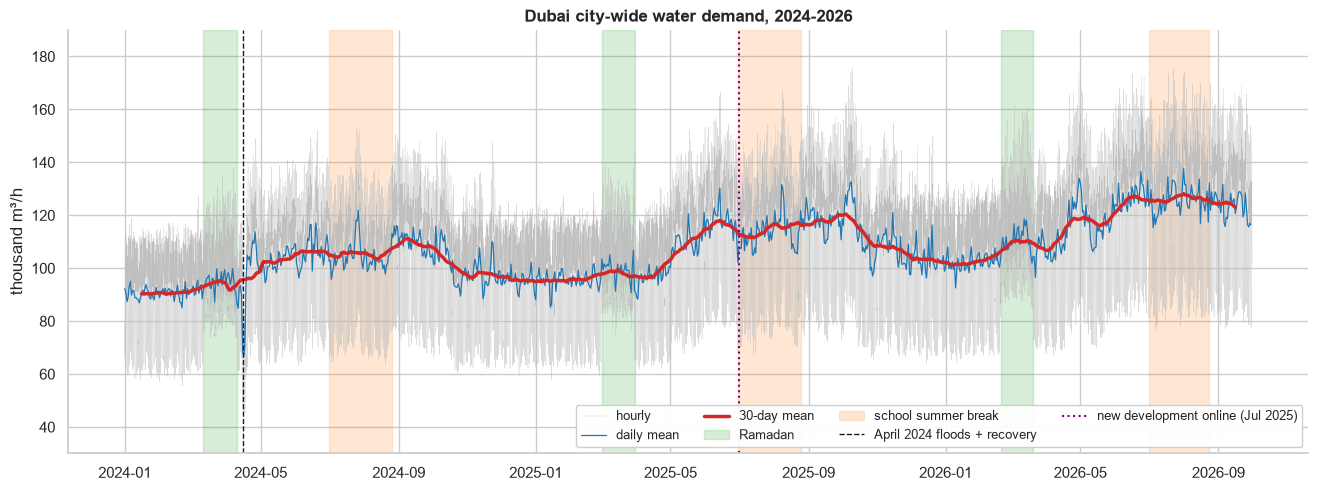

In [10]:
daily = y.resample("D").mean()
calx = cal.set_index("date")
fig, ax = plt.subplots(figsize=(16, 5.5))
ax.plot(y.index, y.values / 1e3, lw=0.2, color="0.75", label="hourly")
ax.plot(daily.index, daily.values / 1e3, lw=0.9, color="tab:blue", label="daily mean")
ax.plot(daily.index, daily.rolling(30, center=True).mean() / 1e3, lw=2.5, color="tab:red", label="30-day mean")

def shade(mask, color, label):
    blocks = (mask != mask.shift()).cumsum()[mask]
    for i, (_, g) in enumerate(blocks.groupby(blocks)):
        ax.axvspan(g.index.min(), g.index.max() + pd.Timedelta(days=1), color=color, alpha=0.18,
                   label=label if i == 0 else None)

shade(calx.is_ramadan, "tab:green", "Ramadan")
shade(calx.is_school_break, "tab:orange", "school summer break")
ax.axvline(pd.Timestamp("2024-04-15"), color="k", ls="--", lw=1, label="April 2024 floods + recovery")
ax.axvline(pd.Timestamp("2025-07-01"), color="purple", ls=":", lw=1.5, label="new development online (Jul 2025)")
ax.set(title="Dubai city-wide water demand, 2024-2026", ylabel="thousand m³/h", ylim=(30, 190))
ax.legend(loc="lower right", ncol=4, fontsize=9, framealpha=0.95)
plt.show()

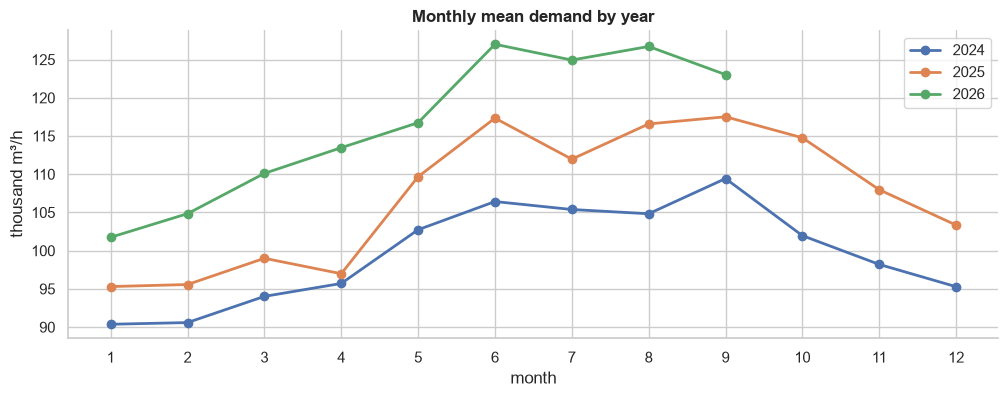

In [11]:
monthly = y.resample("MS").mean().to_frame("mean_m3h")
monthly["year"], monthly["month"] = monthly.index.year, monthly.index.month
fig, ax = plt.subplots(figsize=(12, 4))
for yr, g in monthly.groupby("year"):
    ax.plot(g.month, g.mean_m3h / 1e3, marker="o", lw=2, label=str(yr))
ax.set(title="Monthly mean demand by year", xlabel="month", ylabel="thousand m³/h", xticks=range(1, 13))
ax.legend(); plt.show()

> **Findings - big picture**
> * Three effects are visible straight away: **a strong upward trend**, **an annual cycle** (summer high, winter
>   low), and a **wide intraday range** (the grey hourly band spans roughly 45k-175k m³/h).
> * Every year sits entirely above the one before: the monthly curves stack instead of overlapping.
> * The **April 2024 floods** stand out as a sharp dip, followed by a rebound during the recovery.

## 4. Trend and growth

A growing level matters twice for modelling: it makes the series non-stationary, and **tree models cannot
extrapolate** beyond target values seen in training. We quantify the growth rate and check whether it changed
after the new development came online (July 2025).

Annual statistics (thousand m³/h; 2026 = Jan-Sep):


,mean,median,min,max,growth_vs_prev_%
timestamp_local,,,,,
2024,99.6,101.5,44.9,152.8,NaN
2025,107.2,108.8,57.6,175.4,7.6
2026,116.6,118.3,64.3,175.2,8.8


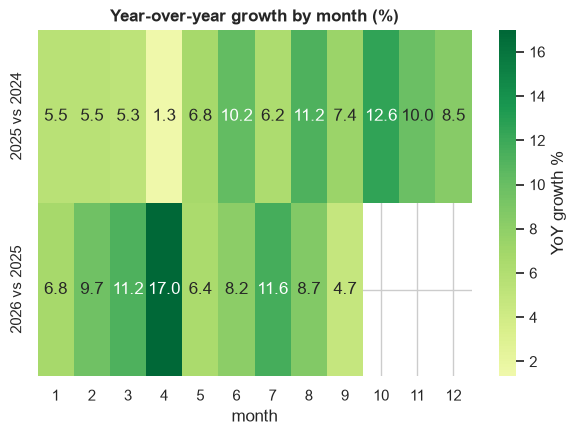

In [12]:
yearly = y.groupby(y.index.year).agg(["mean", "median", "min", "max"]).div(1e3).round(1)
yearly["growth_vs_prev_%"] = (yearly["mean"].pct_change() * 100).round(1)
print("Annual statistics (thousand m³/h; 2026 = Jan-Sep):"); display(yearly)

piv = monthly.pivot(index="month", columns="year", values="mean_m3h")
yoy = pd.DataFrame({"2025 vs 2024": piv[2025] / piv[2024] - 1, "2026 vs 2025": piv[2026] / piv[2025] - 1}) * 100
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(yoy.T, annot=True, fmt=".1f", cmap="RdYlGn", center=0, cbar_kws={"label": "YoY growth %"}, ax=ax)
ax.set(title="Year-over-year growth by month (%)", xlabel="month"); plt.show()

log-linear trend: 9.8 % growth per year
mean YoY growth (28-day smoothed): Jan-Jun 2025 = 5.8 %   vs   Jul 2025 onwards = 9.4 %


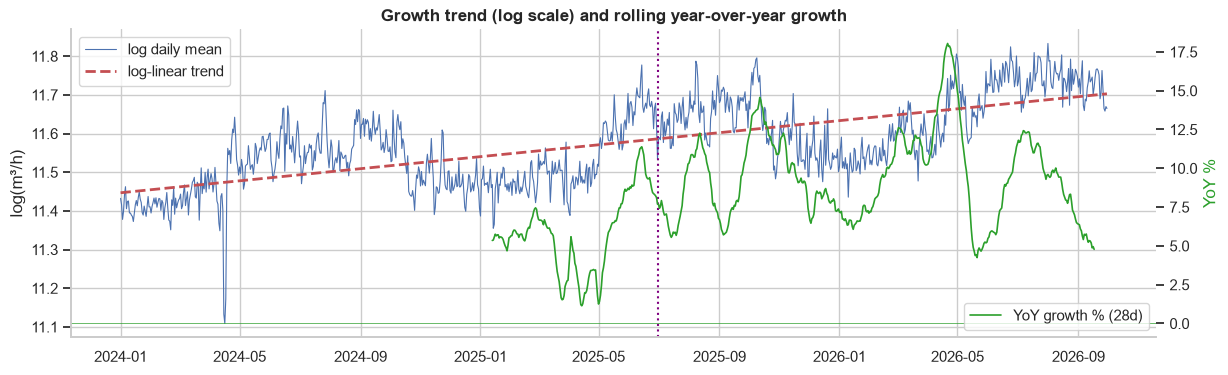

In [13]:
t = (daily.dropna().index - daily.index[0]).days.to_numpy()
b, a = np.polyfit(t, np.log(daily.dropna().to_numpy()), 1)
print(f"log-linear trend: {np.expm1(b * 365) * 100:.1f} % growth per year")

yoy_series = (daily.rolling(28, center=True).mean() / daily.rolling(28, center=True).mean().shift(364) - 1) * 100
pre = yoy_series["2025-01-15":"2025-06-30"].mean()
post = yoy_series["2025-07-01":"2026-09-15"].mean()
print(f"mean YoY growth (28-day smoothed): Jan-Jun 2025 = {pre:.1f} %   vs   Jul 2025 onwards = {post:.1f} %")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, np.log(daily), lw=0.8, label="log daily mean")
ax.plot(daily.index, a + b * (daily.index - daily.index[0]).days, "r--", lw=2, label="log-linear trend")
ax2 = ax.twinx(); ax2.plot(yoy_series.index, yoy_series, color="tab:green", lw=1.2, label="YoY growth % (28d)")
ax2.axhline(0, color="tab:green", lw=0.5); ax2.set_ylabel("YoY %", color="tab:green"); ax2.grid(False)
ax.axvline(pd.Timestamp("2025-07-01"), color="purple", ls=":", lw=1.5)
ax.set(title="Growth trend (log scale) and rolling year-over-year growth", ylabel="log(m³/h)")
ax.legend(loc="upper left"); ax2.legend(loc="lower right"); plt.show()

> **Findings - trend**
> * Demand grows by **about 10 % per year** (annual mean 99.6k → 107.2k → 116.6k m³/h; log-linear fit ≈ 9.8 %/yr).
> * Growth **accelerated after July 2025**, from about 5.8 % YoY in H1 2025 to about 9.4 % afterwards. That
>   is consistent with the *New development online* event (the calendar notes “+~2 % base demand”) on top of
>   organic growth. Single months swing more (e.g. April) because Ramadan and Eid move ~11 days earlier each year.
> * **Modelling implication:** with ~10 %/yr growth, a model trained on the past will under-forecast if it cannot
>   extrapolate the level. We test **normalising the target by a growth trend** in `02_modelling`.

## 5. Distribution

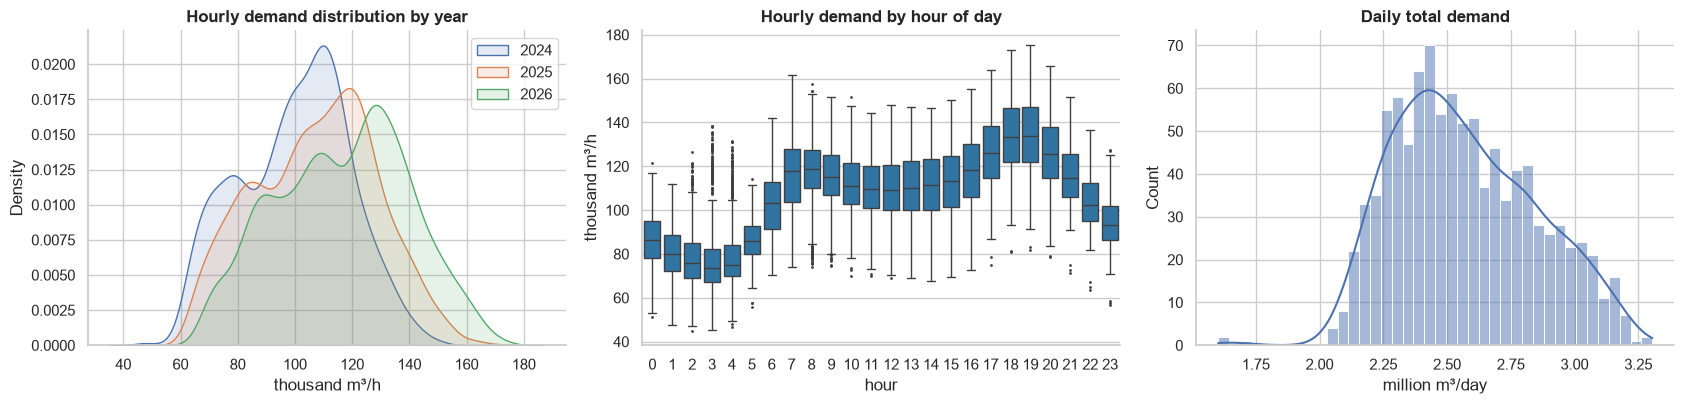

count     24020.0
mean     106983.0
std       22249.0
min       44869.0
25%       90125.0
50%      107672.0
75%      122802.0
max      175428.0
skewness 0.06  |  coefficient of variation 20.8 %


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for yr in sorted(y.index.year.unique()):
    sns.kdeplot(y[str(yr)].dropna() / 1e3, ax=axes[0], label=str(yr), fill=True, alpha=0.15)
axes[0].set(title="Hourly demand distribution by year", xlabel="thousand m³/h"); axes[0].legend()
sns.boxplot(x=y.index.hour, y=y.values / 1e3, ax=axes[1], color="tab:blue", fliersize=1)
axes[1].set(title="Hourly demand by hour of day", xlabel="hour", ylabel="thousand m³/h")
sns.histplot(daily.dropna() * 24 / 1e6, bins=40, kde=True, ax=axes[2])
axes[2].set(title="Daily total demand", xlabel="million m³/day")
plt.tight_layout(); plt.show()
print(y.describe().round(0).to_string())
print(f"skewness {y.skew():.2f}  |  coefficient of variation {y.std()/y.mean()*100:.1f} %")

> **Findings - distribution**
> * Hourly demand ranges from ~45k to ~175k m³/h (mean ~107k, **CV ≈ 21 %**) and is close to symmetric
>   (skew ≈ 0). No transformation is needed for a symmetric loss, and MAPE is well defined (no zeros).
> * The yearly distributions **shift right, keeping their shape**: growth changes the level, not the pattern.
> * Most of the spread comes from **hour of day**: the overnight trough is about half of the evening peak.

## 6. Seasonality

To isolate seasonal effects from growth, demand is expressed **relative to its local level** (each hour divided
by a centred 28-day moving average of daily demand). A value of 1.20 means “20 % above the typical level of
that period”.

In [15]:
trend28 = daily.rolling(28, center=True, min_periods=14).mean()
df = pd.DataFrame({"y": y})
df["date"] = df.index.normalize()
df = df.join(wx.set_index("timestamp_local")[["temperature_c", "apparent_temperature_c", "relative_humidity_pct",
                                              "precipitation_mm", "wind_speed_kmh", "solar_radiation_wm2"]])
df = df.reset_index().merge(cal, on="date", how="left").set_index("timestamp_local")
df["rel"] = df.y / df.date.map(trend28)
df["hour"], df["dow"], df["month"] = df.index.hour, df.index.dayofweek, df.index.month
df["day_type"] = np.select([df.is_public_holiday, df.is_ramadan, df.is_weekend],
                           ["public holiday", "Ramadan", "weekend (Sat-Sun)"], "weekday")
df["season"] = np.select([df.month.isin([5, 6, 7, 8, 9]), df.month.isin([12, 1, 2])],
                         ["summer (May-Sep)", "winter (Dec-Feb)"], "shoulder")

### 6.1 Intraday profile by day type

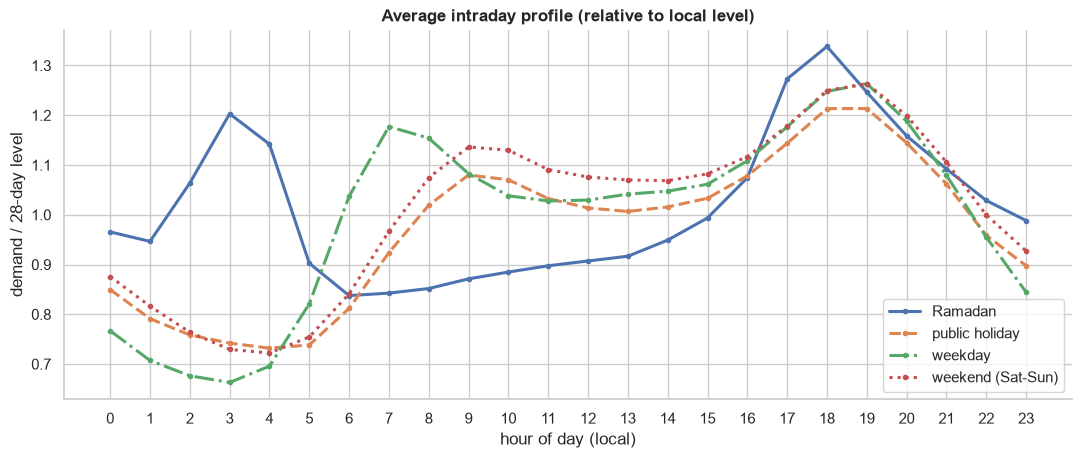

,peak_hour,peak,trough_hour,trough,peak/trough
day_type,,,,,
Ramadan,18,1.34,6,0.84,1.60
public holiday,19,1.21,4,0.73,1.66
weekday,19,1.26,3,0.66,1.91
weekend (Sat-Sun),19,1.26,4,0.72,1.75


In [16]:
prof = df.pivot_table(index="hour", columns="day_type", values="rel", aggfunc="mean")
fig, ax = plt.subplots(figsize=(13, 4.8))
for col, style in zip(prof.columns, ["-", "--", "-.", ":"]):
    ax.plot(prof.index, prof[col], style, lw=2.2, marker="o", ms=3, label=col)
ax.set(title="Average intraday profile (relative to local level)", xlabel="hour of day (local)",
       ylabel="demand / 28-day level", xticks=range(24))
ax.legend(); plt.show()

summary = pd.DataFrame({"peak_hour": prof.idxmax(), "peak": prof.max(), "trough_hour": prof.idxmin(),
                        "trough": prof.min(), "peak/trough": prof.max() / prof.min()}).round(2)
summary

### 6.2 Hour × day-of-week

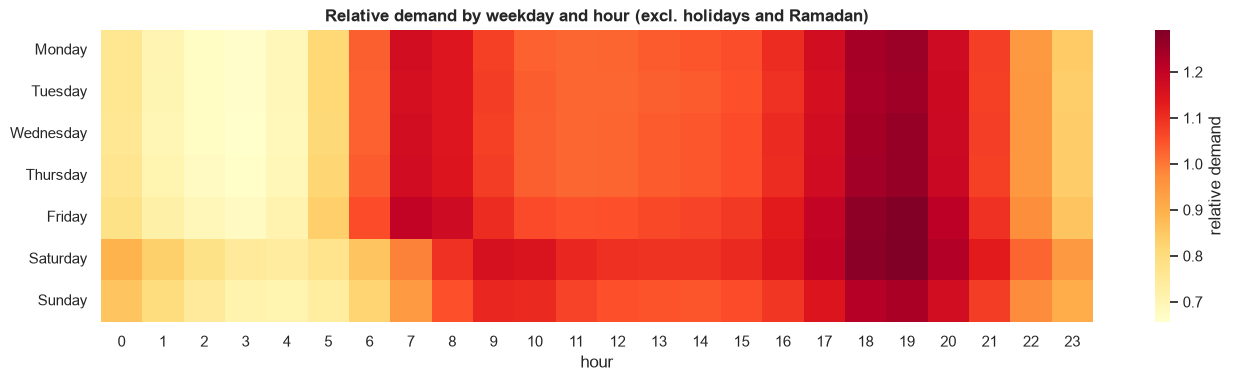

In [17]:
hm = df[~df.is_public_holiday & ~df.is_ramadan].pivot_table(index="dow", columns="hour", values="rel")
hm.index = DOW
fig, ax = plt.subplots(figsize=(16, 3.8))
sns.heatmap(hm, cmap="YlOrRd", ax=ax, cbar_kws={"label": "relative demand"})
ax.set(title="Relative demand by weekday and hour (excl. holidays and Ramadan)", xlabel="hour", ylabel="")
plt.show()

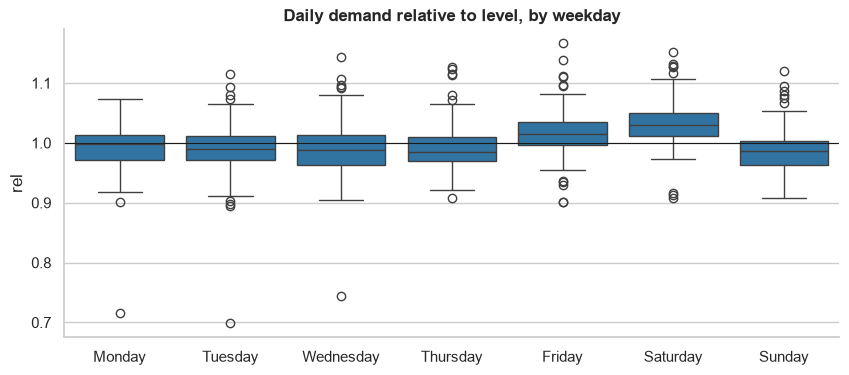

daily level vs Mon-Thu (%): {'Monday': -0.0, 'Tuesday': -0.1, 'Wednesday': -0.0, 'Thursday': 0.2, 'Friday': 2.5, 'Saturday': 4.2, 'Sunday': -0.3}


In [18]:
dd = df.groupby("date").agg(rel=("rel", "mean"), y=("y", "mean"), dow=("dow", "first"),
                            hol=("is_public_holiday", "first"), ram=("is_ramadan", "first"),
                            wkend=("is_weekend", "first"), school=("is_school_break", "first"),
                            month=("month", "first"), tmean=("temperature_c", "mean"),
                            tmax=("temperature_c", "max"), rain=("precipitation_mm", "sum"),
                            hum=("relative_humidity_pct", "mean"), app=("apparent_temperature_c", "mean"),
                            wind=("wind_speed_kmh", "mean"), solar=("solar_radiation_wm2", "mean"))
normal = dd[~dd.hol & ~dd.ram]
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=normal.dow.map(dict(enumerate(DOW))), y=normal.rel, order=DOW, ax=ax, color="tab:blue")
ax.axhline(1, color="k", lw=0.8); ax.set(title="Daily demand relative to level, by weekday", xlabel="", ylabel="rel")
plt.show()
dow_effect = (normal.groupby("dow").rel.mean() / normal[normal.dow < 4].rel.mean() - 1) * 100
print("daily level vs Mon-Thu (%):", {DOW[k]: round(v, 1) for k, v in dow_effect.items()})

### 6.3 Annual cycle

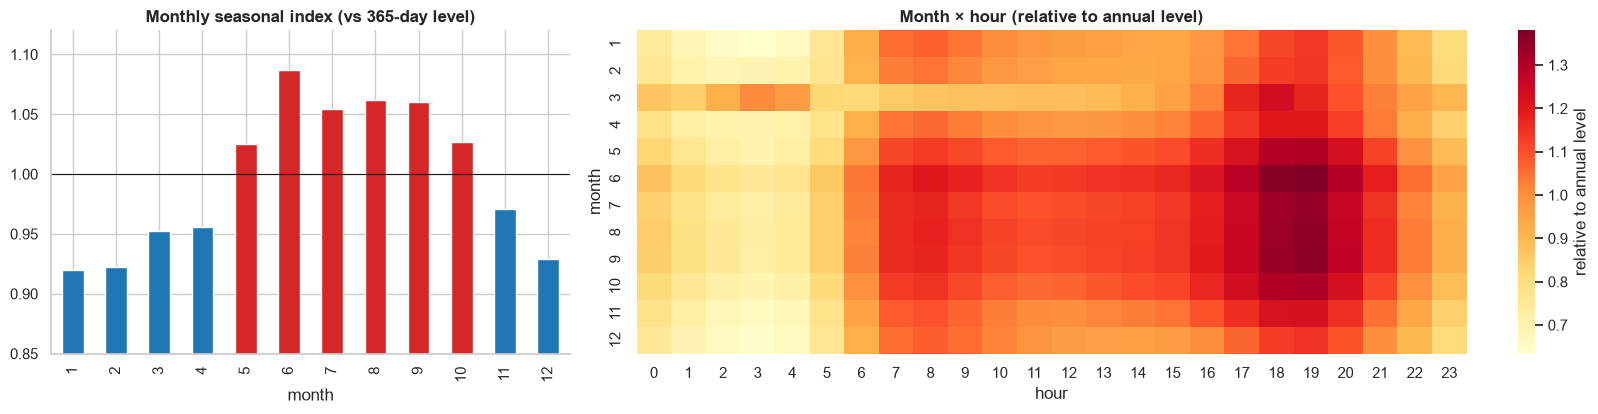

seasonal index: {1: 0.92, 2: 0.922, 3: 0.953, 4: 0.956, 5: 1.025, 6: 1.087, 7: 1.054, 8: 1.062, 9: 1.06, 10: 1.027, 11: 0.97, 12: 0.929}
summer peak / winter trough: 1.182


In [19]:
trend365 = daily.rolling(365, center=True, min_periods=180).mean()
season_idx = (daily / trend365).groupby(daily.index.month).mean()
mh = df.assign(rel365=df.y / df.date.map(trend365)).pivot_table(index="month", columns="hour", values="rel365")

fig, axes = plt.subplots(1, 2, figsize=(17, 4.3), gridspec_kw={"width_ratios": [1, 2]})
season_idx.plot.bar(ax=axes[0], color=["tab:blue" if v < 1 else "tab:red" for v in season_idx])
axes[0].axhline(1, color="k", lw=0.8)
axes[0].set(title="Monthly seasonal index (vs 365-day level)", xlabel="month", ylim=(0.85, 1.12))
sns.heatmap(mh, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "relative to annual level"})
axes[1].set(title="Month × hour (relative to annual level)", xlabel="hour", ylabel="month")
plt.tight_layout(); plt.show()
print("seasonal index:", season_idx.round(3).to_dict())
print(f"summer peak / winter trough: {season_idx.max() / season_idx.min():.3f}")

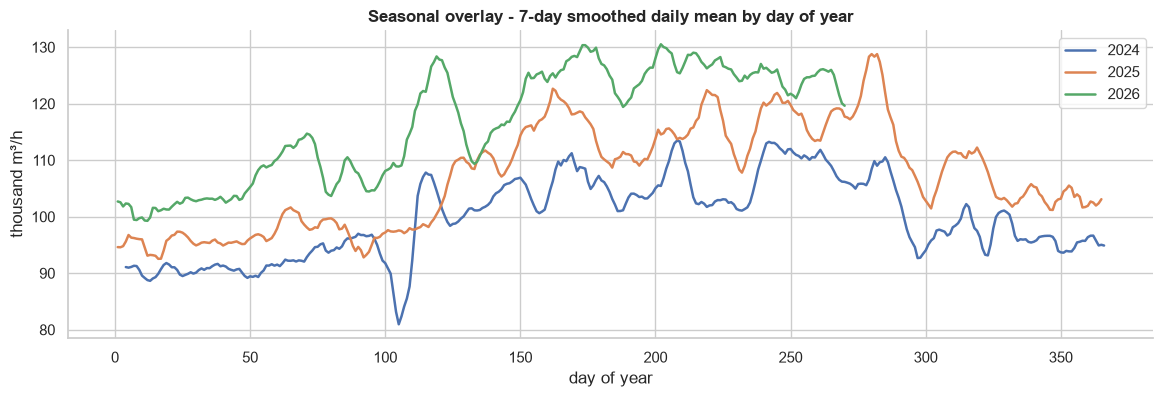

In [20]:
fig, ax = plt.subplots(figsize=(14, 4))
sm = daily.rolling(7, center=True).mean()
for yr in sorted(sm.index.year.unique()):
    s = sm[str(yr)]
    ax.plot(s.index.dayofyear, s.values / 1e3, lw=1.8, label=str(yr))
ax.set(title="Seasonal overlay - 7-day smoothed daily mean by day of year", xlabel="day of year",
       ylabel="thousand m³/h"); ax.legend(); plt.show()

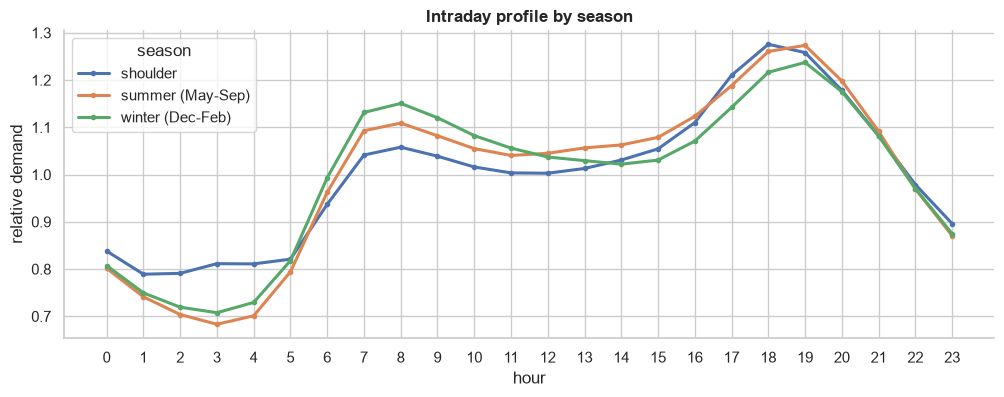

In [21]:
sp = df.pivot_table(index="hour", columns="season", values="rel")
ax = sp.plot(figsize=(12, 4), lw=2.2, marker="o", ms=3)
ax.set(title="Intraday profile by season", xlabel="hour", ylabel="relative demand", xticks=range(24)); plt.show()

> **Findings - seasonality**
> * **Daily cycle (dominant):** on weekdays the trough is at **03:00 (0.66)**, a morning peak at 07-08:00 and the
>   main **evening peak at 19:00 (1.26)** - a **peak/trough ratio of about 1.9**. Weekends and holidays are flatter
>   (about 1.7), with a later morning ramp: no commuting peak.
> * **Weekly cycle (weak):** the UAE weekend is **Saturday-Sunday**. **Saturday is about 4 % above Mon-Thu,
>   Friday about 2.5 %** (evenly across all hours, not a half-day shape), Sunday is close to a weekday. The
>   weekly signal is much weaker than the daily one (see Section 7).
> * **Annual cycle:** from about **0.92 in Jan/Feb to about 1.09 in June** - roughly **±9 % around the annual level**,
>   following temperature. Summer nights sit *lower* relative to the day (larger daytime/evening cooling and
>   irrigation load).

## 7. Decomposition

**MSTL** (multiple seasonal-trend decomposition by LOESS) separates the hourly series into trend + daily (24 h) +
weekly (168 h) seasonality + remainder. We use the last full year. The *strength* of each component follows
Hyndman & Athanasopoulos: F = max(0, 1 − Var(remainder) / Var(component + remainder)).

component strength: {'trend': np.float64(0.872), 'daily (24h)': np.float64(0.966), 'weekly (168h)': np.float64(0.572)}
remainder std = 3,729 m³/h  = 3.27 % of mean demand


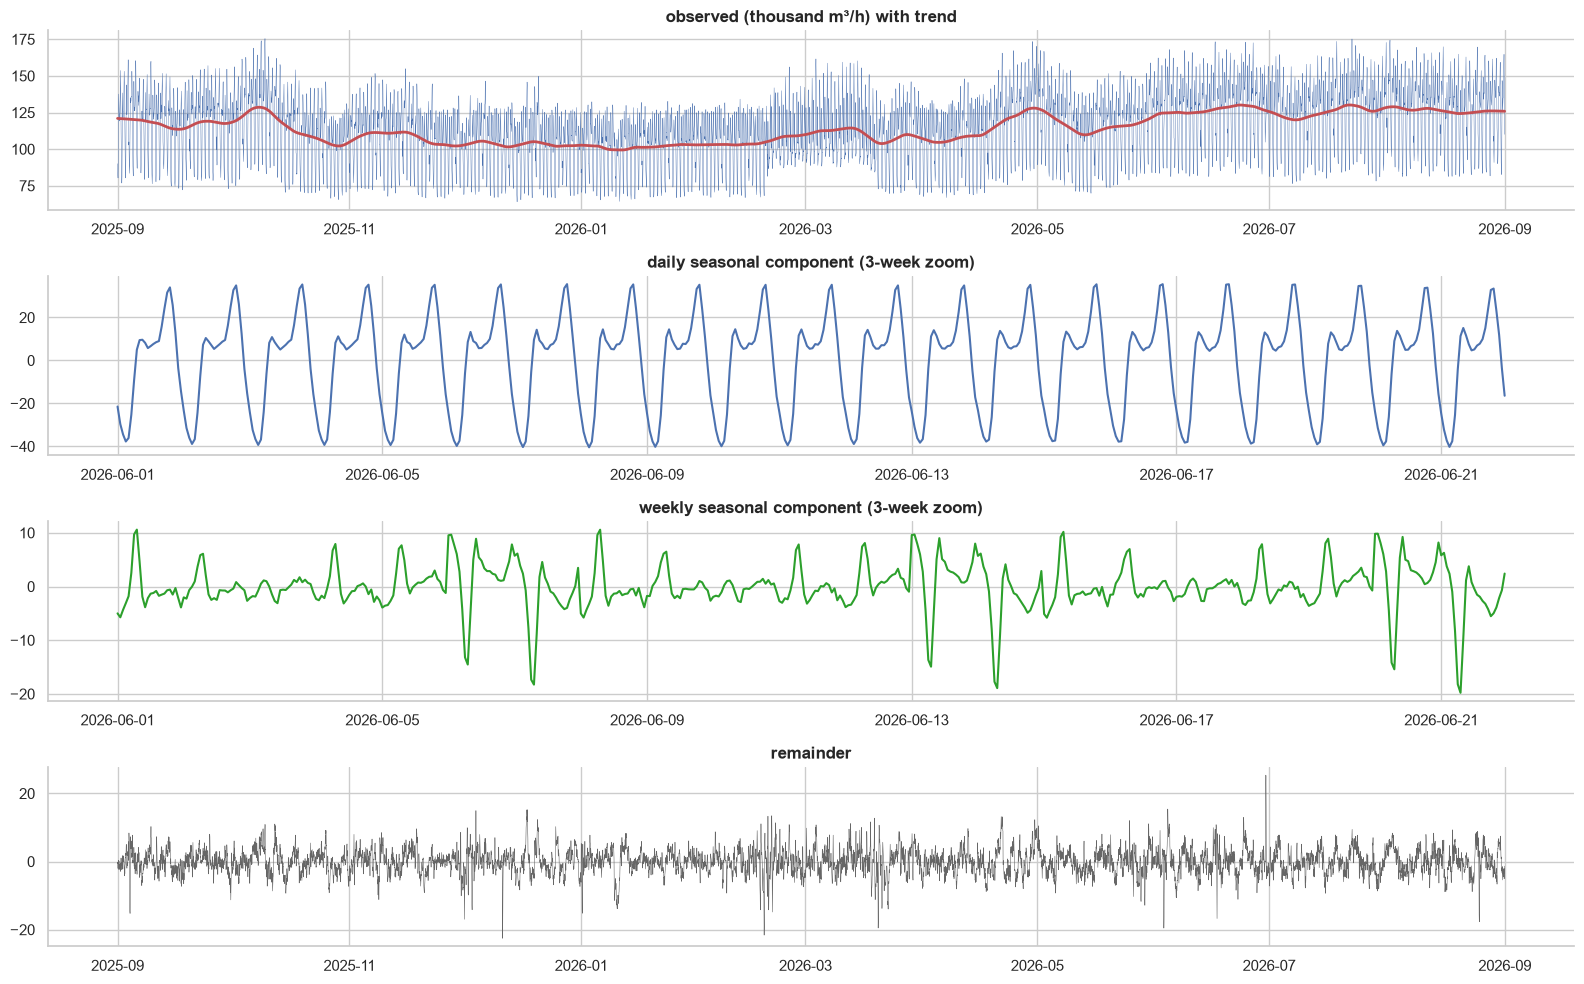

In [22]:
y1 = y_filled["2025-09-01":"2026-08-31"].interpolate()
mstl = MSTL(y1, periods=(24, 168)).fit()
rem = mstl.resid
strength = {
    "trend": 1 - rem.var() / (mstl.trend + rem).var(),
    "daily (24h)": 1 - rem.var() / (mstl.seasonal["seasonal_24"] + rem).var(),
    "weekly (168h)": 1 - rem.var() / (mstl.seasonal["seasonal_168"] + rem).var(),
}
print("component strength:", {k: round(max(v, 0), 3) for k, v in strength.items()})
print(f"remainder std = {rem.std():,.0f} m³/h  = {rem.std() / y1.mean() * 100:.2f} % of mean demand")

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=False)
axes[0].plot(y1.index, y1 / 1e3, lw=0.3); axes[0].plot(mstl.trend.index, mstl.trend / 1e3, "r", lw=2)
axes[0].set_title("observed (thousand m³/h) with trend")
win = slice("2026-06-01", "2026-06-21")
axes[1].plot(mstl.seasonal["seasonal_24"][win] / 1e3); axes[1].set_title("daily seasonal component (3-week zoom)")
axes[2].plot(mstl.seasonal["seasonal_168"][win] / 1e3, color="tab:green")
axes[2].set_title("weekly seasonal component (3-week zoom)")
axes[3].plot(rem.index, rem / 1e3, lw=0.4, color="0.4"); axes[3].set_title("remainder")
plt.tight_layout(); plt.show()

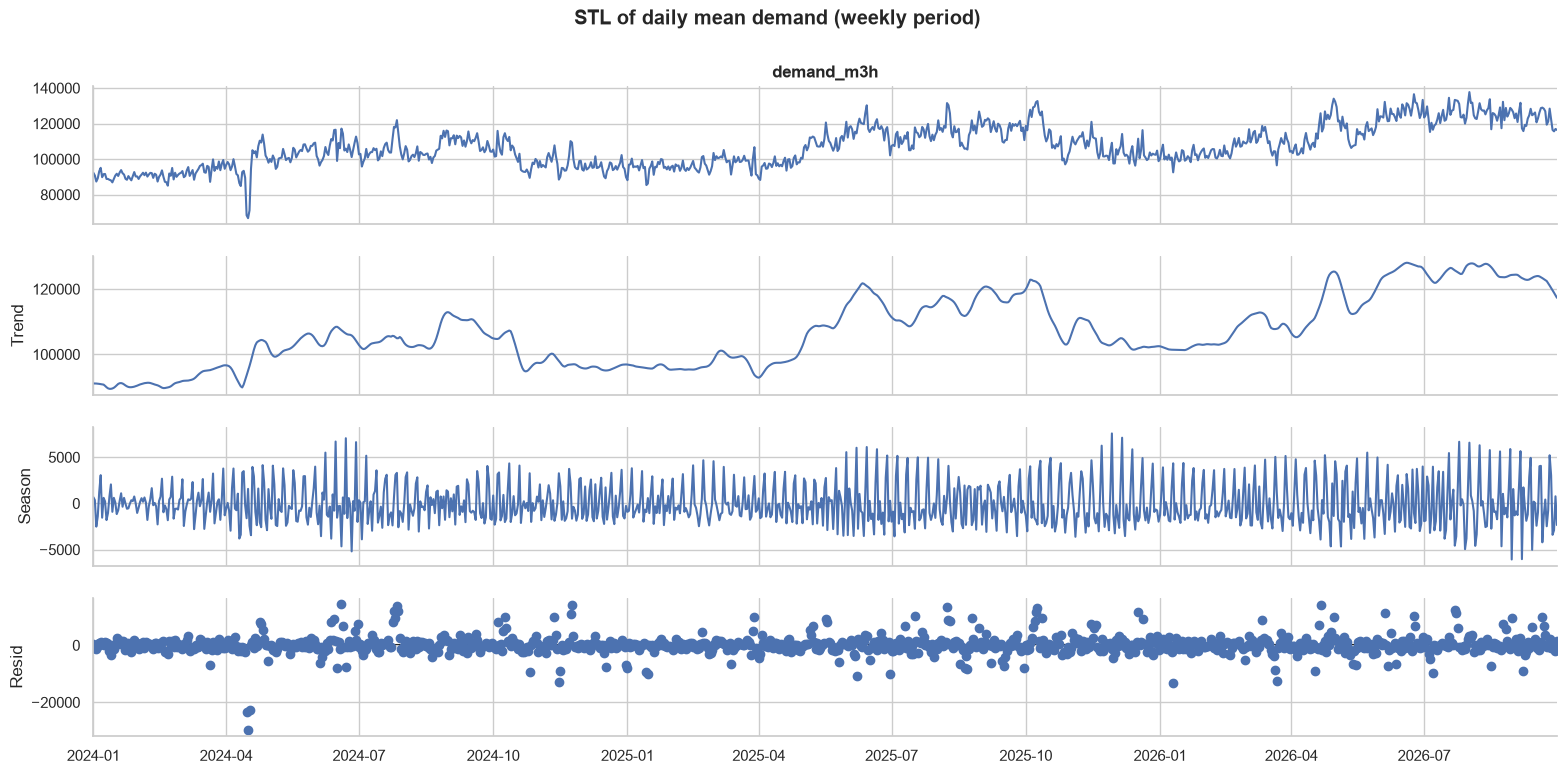

In [23]:
stl_d = STL(daily.interpolate(), period=7, robust=True).fit()
fig = stl_d.plot(); fig.set_size_inches(16, 8)
fig.suptitle("STL of daily mean demand (weekly period)", y=1.01, fontweight="bold"); plt.show()

> **Findings - decomposition**
> * **Daily seasonality is by far the strongest structure (F ≈ 0.97)**; the trend is strong too (F ≈ 0.87); the
>   **weekly seasonality is only moderate (F ≈ 0.57)**, confirming Section 6.
> * After removing trend + daily + weekly patterns, **the remainder std is about 3.3 % of mean demand**. That is
>   roughly the error of a “calendar-only” model. To beat it, a model must explain day-to-day deviations:
>   **weather, holidays, Ramadan** (next sections).

## 8. Stationarity

ADF (null hypothesis: unit root, i.e. non-stationary) and KPSS (null hypothesis: stationary) complement each
other: *ADF rejects + KPSS does not reject* → stationary.

In [24]:
def stationarity(series, name):
    s = series.dropna()
    return {"series": name, "ADF p-value": adfuller(s, autolag="AIC")[1],
            "KPSS p-value": kpss(s, regression="c", nlags="auto")[1]}

x = y_filled["2024-06-01":].interpolate().dropna()
dl = daily.interpolate()
st = pd.DataFrame([
    stationarity(x, "hourly level"),
    stationarity(dl, "daily level"),
    stationarity(dl.diff(), "daily, 1st difference"),
    stationarity(x.diff(168), "hourly, seasonal difference (168h)"),
    stationarity(dl / trend28, "daily / 28-day level"),
])
st["verdict"] = np.where((st["ADF p-value"] < 0.05) & (st["KPSS p-value"] > 0.05), "stationary",
                np.where((st["ADF p-value"] >= 0.05) & (st["KPSS p-value"] <= 0.05), "non-stationary",
                         "trend-stationary / mixed"))
st.round(4)

,series,ADF p-value,KPSS p-value,verdict
0,hourly level,0.0001,0.01,trend-stationary / mixed
1,daily level,0.2992,0.01,non-stationary
2,"daily, 1st difference",0.0000,0.10,stationary
3,"hourly, seasonal difference (168h)",0.0000,0.10,stationary
4,daily / 28-day level,0.0000,0.10,stationary


> **Findings - stationarity**
> * The **daily level is non-stationary** (ADF p ≈ 0.30, KPSS rejects). The hourly level gives mixed results
>   (ADF rejects because of the strong daily cycle, KPSS rejects because of the trend).
> * **First differencing, seasonal differencing, or dividing by the local level** all give a stationary series.
> * **Implication:** classical ARIMA-type models need differencing (d = 1). ML models should work on **scale-free
>   quantities** - ratios to a level or to a trend - rather than on the raw, drifting level.

## 9. Autocorrelation - which lags carry information, and which may we use?

The forecast is issued in the morning of day **D** for all 24 hours of **D+1**. The newest *complete* day of
actuals at that moment is **D−1**. So for a target hour on D+1, the shortest lag that is always known is
**48 h** (same hour on D−1). **Lag 24 (same hour on D) has not happened yet at issue time**; using it would be
data leakage.

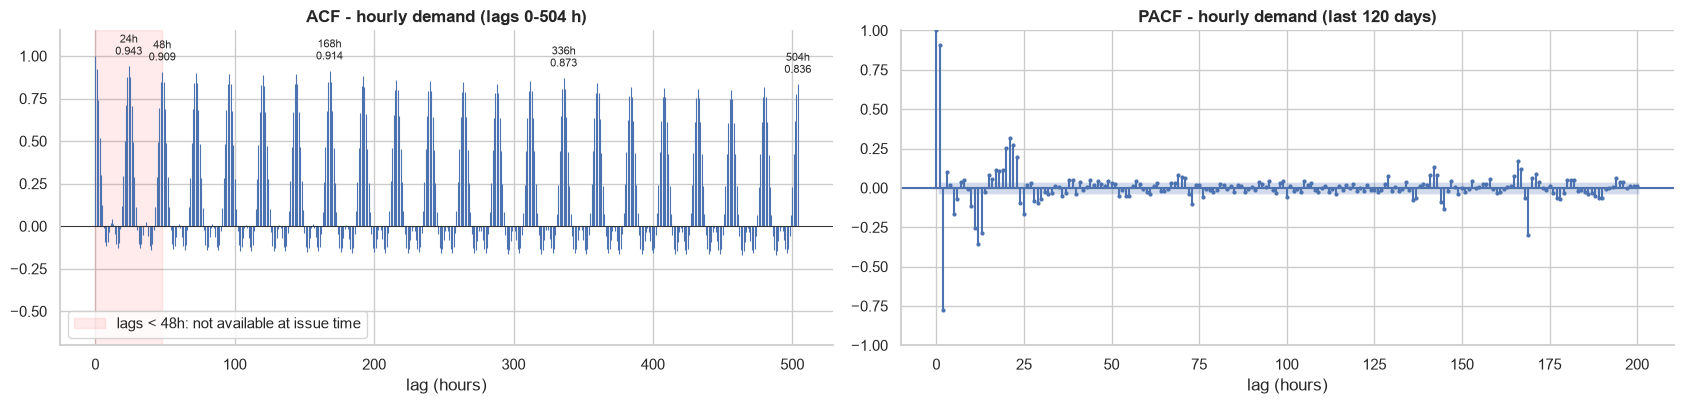

In [25]:
a = acf(x, nlags=504, fft=True)
fig, axes = plt.subplots(1, 2, figsize=(17, 4.2))
axes[0].vlines(range(len(a)), 0, a, lw=0.8)
axes[0].axvspan(0, 47.5, color="red", alpha=0.08, label="lags < 48h: not available at issue time")
for L in (24, 48, 168, 336, 504):
    axes[0].annotate(f"{L}h\n{a[L]:.3f}", (L, a[L]), textcoords="offset points", xytext=(0, 8), ha="center",
                     fontsize=8)
axes[0].axhline(0, color="k", lw=0.6)
axes[0].set(title="ACF - hourly demand (lags 0-504 h)", xlabel="lag (hours)", ylim=(-0.7, 1.15))
axes[0].legend(loc="lower left")
plot_pacf(x.iloc[-24 * 120:], lags=200, method="ywm", ax=axes[1], markersize=2)
axes[1].set(title="PACF - hourly demand (last 120 days)", xlabel="lag (hours)")
plt.tight_layout(); plt.show()

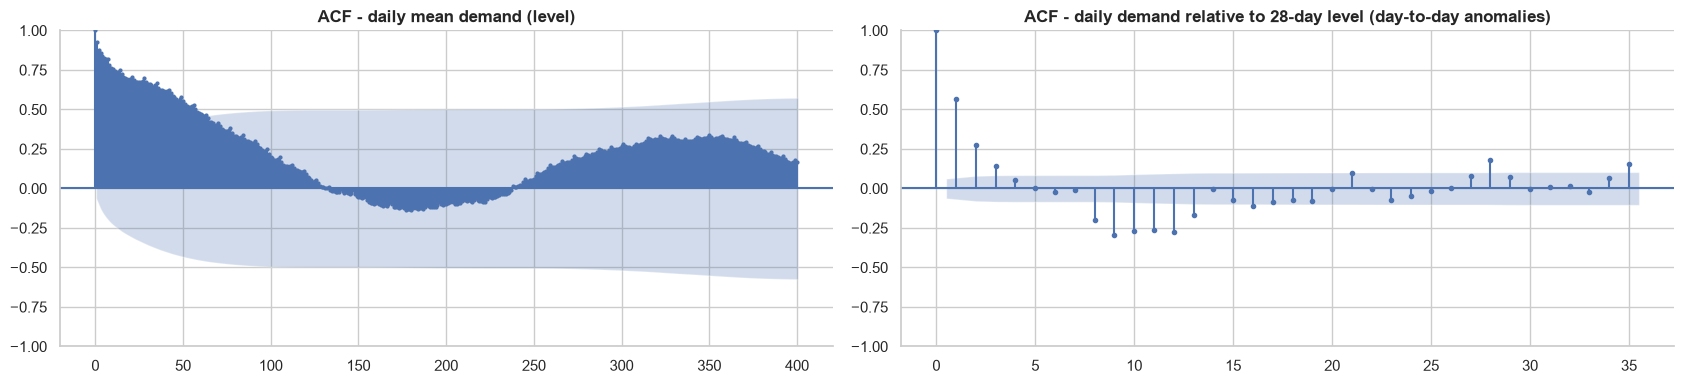

,lag,autocorrelation,usable at issue time?
0,1 h,0.923,no
1,24 h,0.943,no
2,48 h,0.909,yes
3,168 h,0.914,yes
4,336 h,0.873,yes
5,504 h,0.836,yes
6,1 day (anomaly),0.568,no
7,2 days (anomaly),0.274,yes


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(17, 4))
plot_acf(dl, lags=400, ax=axes[0], markersize=2); axes[0].set_title("ACF - daily mean demand (level)")
detr = (daily / trend28).dropna()
plot_acf(detr, lags=35, ax=axes[1], markersize=3)
axes[1].set_title("ACF - daily demand relative to 28-day level (day-to-day anomalies)")
plt.tight_layout(); plt.show()

ad = acf(detr, nlags=7)
key = pd.DataFrame({
    "lag": ["1 h", "24 h", "48 h", "168 h", "336 h", "504 h", "1 day (anomaly)", "2 days (anomaly)"],
    "autocorrelation": [a[1], a[24], a[48], a[168], a[336], a[504], ad[1], ad[2]],
    "usable at issue time?": ["no", "no", "yes", "yes", "yes", "yes", "no", "yes"],
}).round(3)
key

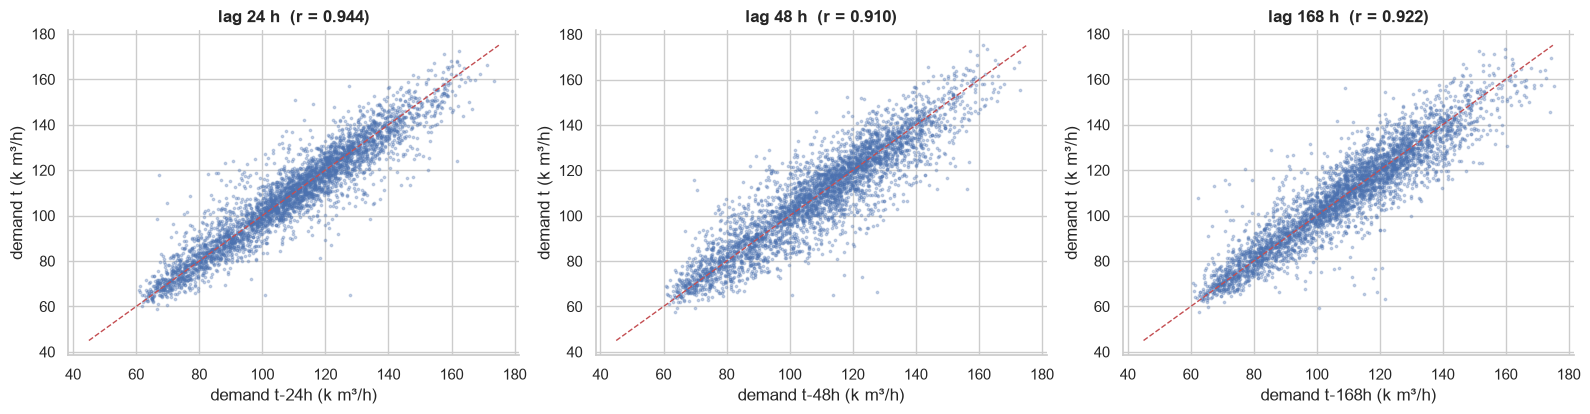

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, L in zip(axes, (24, 48, 168)):
    pair = pd.DataFrame({"t": x, "lag": x.shift(L)}).dropna().sample(4000, random_state=0) / 1e3
    ax.scatter(pair.lag, pair.t, s=3, alpha=0.3)
    ax.plot([45, 175], [45, 175], "r--", lw=1)
    ax.set(title=f"lag {L} h  (r = {x.corr(x.shift(L)):.3f})", xlabel=f"demand t-{L}h (k m³/h)",
           ylabel="demand t (k m³/h)")
plt.tight_layout(); plt.show()

> **Findings - autocorrelation**
> * The hourly ACF peaks at every multiple of 24 h, with a secondary lift at 168 h (weekly). **Lag 24 (0.943) is
>   only slightly more correlated than lag 48 (0.909) or lag 168 (0.914)** at the hourly level, because most of
>   that correlation is just the shared daily shape.
> * The difference shows up in the **day-to-day anomalies** (demand relative to its level): persistence is
>   **0.57 after one day but 0.27 after two**. Yesterday's anomaly (heat, a holiday mood, an incident) would
>   carry real extra information. Under the current issue time it is not available.
> * **Why there is no `lag_24` feature - it is not an oversight.** At issue time (morning of D), the same hour on
>   D is still in the future. A model trained with lag 24 would look better in a backtest and could not run in
>   production. `features.py` enforces this (`min_lag_hours = 48`).
> * **Review point for the business:** if the forecast could be issued **around midnight**, with near-real-time
>   SCADA data through the end of D, lag 24 would become legitimate. `02_modelling.ipynb` quantifies the
>   accuracy that would gain (*“lag-24 what-if”*), so the issue time can be decided on evidence.
> * The PACF cuts off after about 2 lags, plus seasonal spikes around 24/168 h: short-term dynamics are strong
>   but unusable day-ahead. **Weekly lags (168/336/504 h) and the 48 h lag** are the usable memory.

## 10. Weather drivers

### 10.1 Temperature - the dominant driver

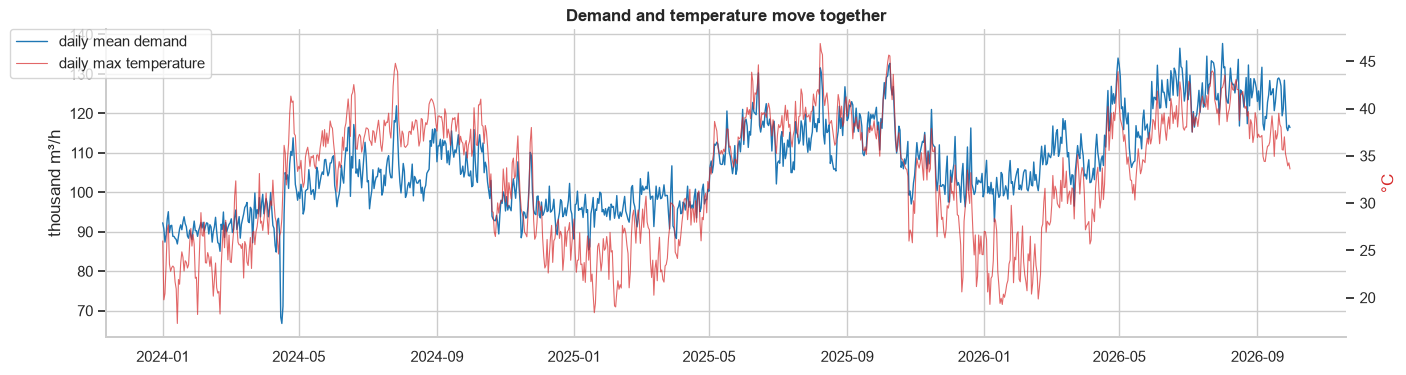

In [28]:
dd["rel365"] = dd.y / dd.index.map(trend365)
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(dd.index, dd.y / 1e3, color="tab:blue", lw=1, label="daily mean demand")
ax2 = ax.twinx(); ax2.plot(dd.index, dd.tmax, color="tab:red", lw=0.8, alpha=0.7, label="daily max temperature")
ax.set(title="Demand and temperature move together", ylabel="thousand m³/h"); ax2.set_ylabel("°C", color="tab:red")
ax2.grid(False); fig.legend(loc="upper left", bbox_to_anchor=(0.06, 0.9)); plt.show()

piecewise-linear fit: flat below 24.4 °C, then +1.44 % demand per °C of daily mean temperature


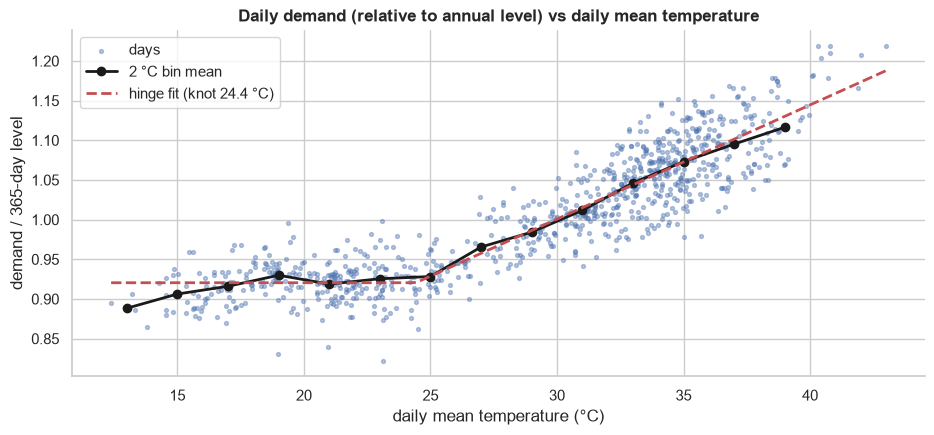

In [29]:
from scipy.optimize import minimize_scalar

sub = dd.dropna(subset=["rel365", "tmean"])
sub = sub[~sub.hol & ~sub.ram & (sub.rain < 20)]

def hinge_sse(th):
    Xh = np.column_stack([np.ones(len(sub)), np.clip(sub.tmean - th, 0, None)])
    beta, *_ = np.linalg.lstsq(Xh, sub.rel365, rcond=None)
    return ((sub.rel365 - Xh @ beta) ** 2).sum()

th = minimize_scalar(hinge_sse, bounds=(18, 32), method="bounded").x
Xh = np.column_stack([np.ones(len(sub)), np.clip(sub.tmean - th, 0, None)])
beta, *_ = np.linalg.lstsq(Xh, sub.rel365, rcond=None)
print(f"piecewise-linear fit: flat below {th:.1f} °C, then +{beta[1]*100:.2f} % demand per °C of daily mean temperature")

bins = pd.cut(sub.tmean, np.arange(12, 42, 2))
binned = sub.groupby(bins).rel365.agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(sub.tmean, sub.rel365, s=8, alpha=0.4, label="days")
ax.plot([b.mid for b in binned.index], binned["mean"], "ko-", lw=2, label="2 °C bin mean")
tt = np.linspace(sub.tmean.min(), sub.tmean.max(), 100)
ax.plot(tt, beta[0] + beta[1] * np.clip(tt - th, 0, None), "r--", lw=2, label=f"hinge fit (knot {th:.1f} °C)")
ax.set(title="Daily demand (relative to annual level) vs daily mean temperature", xlabel="daily mean temperature (°C)",
       ylabel="demand / 365-day level"); ax.legend(); plt.show()

### 10.2 Other weather variables and collinearity

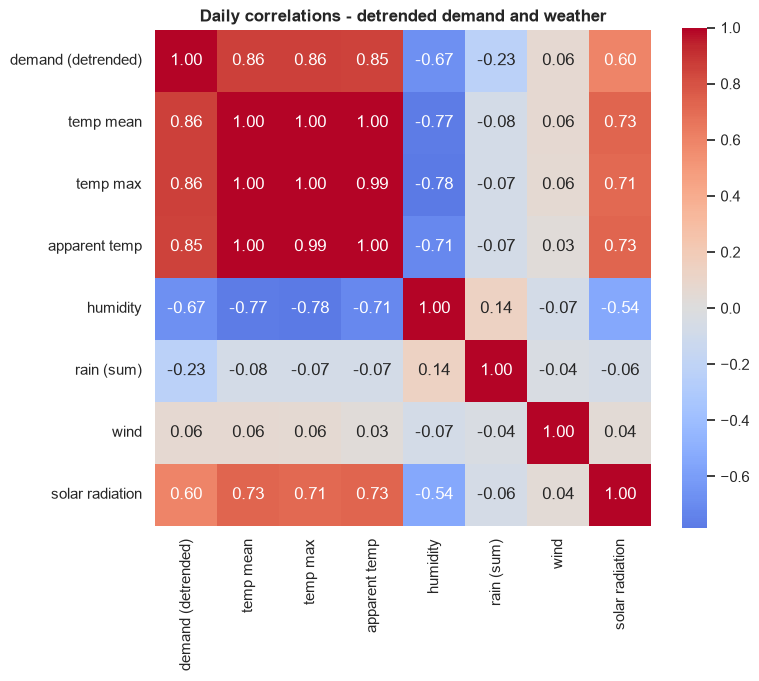

In [30]:
wcols = {"rel365": "demand (detrended)", "tmean": "temp mean", "tmax": "temp max", "app": "apparent temp",
         "hum": "humidity", "rain": "rain (sum)", "wind": "wind", "solar": "solar radiation"}
corr = dd[list(wcols)].rename(columns=wcols).corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Daily correlations - detrended demand and weather"); plt.show()

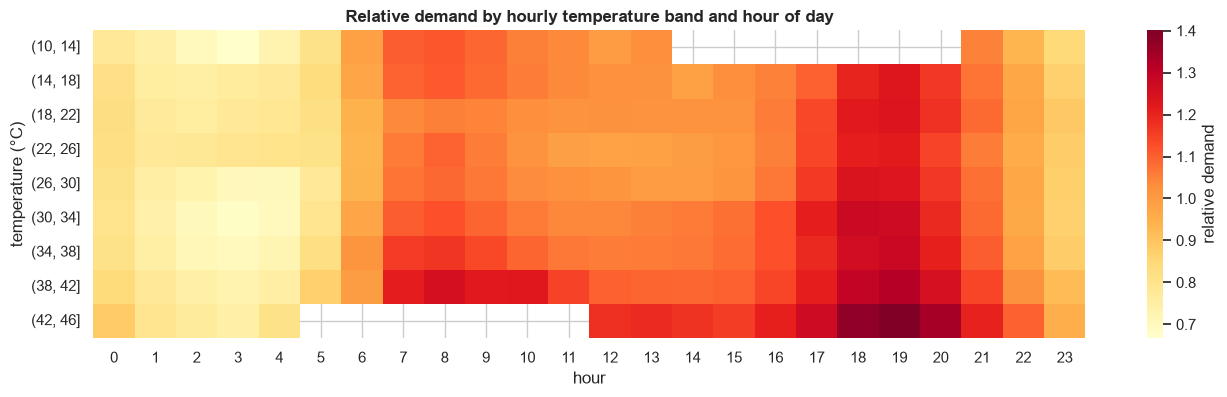

In [31]:
tb = df.assign(tbin=pd.cut(df.temperature_c, np.arange(10, 50, 4))).pivot_table(
    index="tbin", columns="hour", values="rel", observed=True)
fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(tb, cmap="YlOrRd", ax=ax, cbar_kws={"label": "relative demand"})
ax.set(title="Relative demand by hourly temperature band and hour of day", xlabel="hour", ylabel="temperature (°C)")
plt.show()

In [32]:
anom_d = (dd.y / dd.index.map(trend28)).rename("demand_anom")
t_anom = (dd.tmean - dd.tmean.rolling(28, center=True, min_periods=14).mean()).rename("temp_anom")
lagcorr = {f"temp anomaly lag {k} d": anom_d.corr(t_anom.shift(k)) for k in range(0, 4)}
print("thermal inertia - corr(demand anomaly, temperature anomaly k days earlier):",
      {k: round(v, 3) for k, v in lagcorr.items()})

rain = dd.assign(rainy=np.where(dd.rain > 1, "rain > 1 mm", "dry"))
rain = rain[~rain.index.isin(cal[cal.event_type.isin(["weather", "operational"])].date)]
print("detrended demand, dry vs rainy days (floods excluded):", rain.groupby("rainy").rel.mean().round(3).to_dict(),
      "| rainy days:", int((dd.rain > 1).sum()))

thermal inertia - corr(demand anomaly, temperature anomaly k days earlier): {'temp anomaly lag 0 d': np.float64(0.619), 'temp anomaly lag 1 d': np.float64(0.461), 'temp anomaly lag 2 d': np.float64(0.324), 'temp anomaly lag 3 d': np.float64(0.215)}
detrended demand, dry vs rainy days (floods excluded): {'dry': 1.002, 'rain > 1 mm': 0.976} | rainy days: 44


### 10.3 How good is the weather forecast we will actually use?

temperature forecast: bias +0.03 °C | MAE 0.90 °C | RMSE 1.12 °C | humidity MAE 3.2 pp


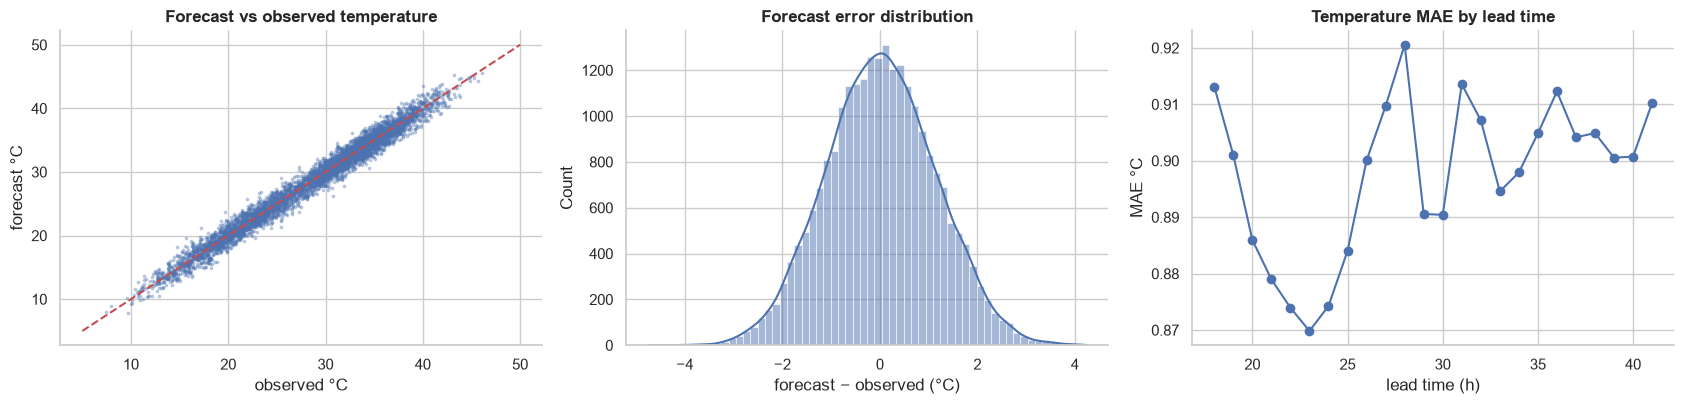

observed rain,False,True
forecast rain,,
False,23826,54
True,76,140


In [33]:
f = fc.merge(wx[["timestamp_local", "temperature_c", "relative_humidity_pct", "precipitation_mm"]], on="timestamp_local")
f["lead_h"] = (f.timestamp_local - f.forecast_issued_local).dt.total_seconds() / 3600
f["t_err"] = f.forecast_temperature_c - f.temperature_c
print(f"temperature forecast: bias {f.t_err.mean():+.2f} °C | MAE {f.t_err.abs().mean():.2f} °C | "
      f"RMSE {np.sqrt((f.t_err**2).mean()):.2f} °C | humidity MAE "
      f"{(f.forecast_relative_humidity_pct - f.relative_humidity_pct).abs().mean():.1f} pp")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
samp = f.sample(5000, random_state=1)
axes[0].scatter(samp.temperature_c, samp.forecast_temperature_c, s=3, alpha=0.3)
axes[0].plot([5, 50], [5, 50], "r--"); axes[0].set(title="Forecast vs observed temperature", xlabel="observed °C", ylabel="forecast °C")
sns.histplot(f.t_err, bins=60, ax=axes[1], kde=True); axes[1].set(title="Forecast error distribution", xlabel="forecast − observed (°C)")
f.groupby(f.lead_h.round()).t_err.apply(lambda e: e.abs().mean()).plot(ax=axes[2], marker="o")
axes[2].set(title="Temperature MAE by lead time", xlabel="lead time (h)", ylabel="MAE °C")
plt.tight_layout(); plt.show()
rain_ct = pd.crosstab(f.forecast_precipitation_mm > 0.1, f.precipitation_mm > 0.1,
                      rownames=["forecast rain"], colnames=["observed rain"])
rain_ct

> **Findings - weather**
> * **Temperature is the strongest external driver.** Correlation with detrended daily demand is **0.86** (mean or
>   max temperature; apparent temperature 0.85).
> * The response is a **hinge, not a line**: demand is roughly flat below **~24.4 °C daily mean** and then rises
>   by about **1.4 % per °C** (piecewise fit above). -> **Review point:** production uses a cooling-degree
>   threshold of **20 °C** and a heating-degree term at 12 °C. For Dubai the knot is nearer 25 °C, and heating
>   demand hardly exists (the daily mean rarely drops below 15 °C).
> * The hot hours drive the effect: the temperature × hour heatmap shows the uplift concentrated in the
>   **afternoon and evening**.
> * **Humidity (−0.67) and solar radiation (+0.60) are mostly proxies for temperature** (strong mutual
>   correlation). Wind adds almost nothing. **Rain lowers demand by about 2.6 %** on rainy days (less irrigation),
>   but it is rare (44 days > 1 mm in 2.75 years).
> * **Temperature effects persist over several days.** The demand anomaly correlates 0.62 with the same-day
>   temperature anomaly, 0.46 with the previous day's and 0.32 with the day before that. Part of this is heat
>   waves lasting several days (temperature anomalies are themselves autocorrelated), and part is genuine inertia
>   (buildings, pools, irrigation schedules). -> Worth testing a **recent observed temperature** feature
>   (e.g. the D−1 mean, available at issue time) alongside the forecast.
> * **The day-ahead forecast is good:** temperature **MAE ≈ 0.9 °C, no bias**, and error barely grows from 18 h to
>   41 h lead. At ~1.4 %/°C above the knot, forecast error alone can cost **around 1 %** of demand accuracy on hot
>   days - an irreducible part of day-ahead error. Rain forecasts catch **72 %** of rainy hours (140 of 194) with
>   76 false alarms.
> * **Training must use the forecast, not the observed weather:** the model has to learn from the same noisy
>   input it will receive in production (no train/serve skew).

## 11. Calendar effects - holidays, Ramadan, school breaks

### 11.1 Public holidays

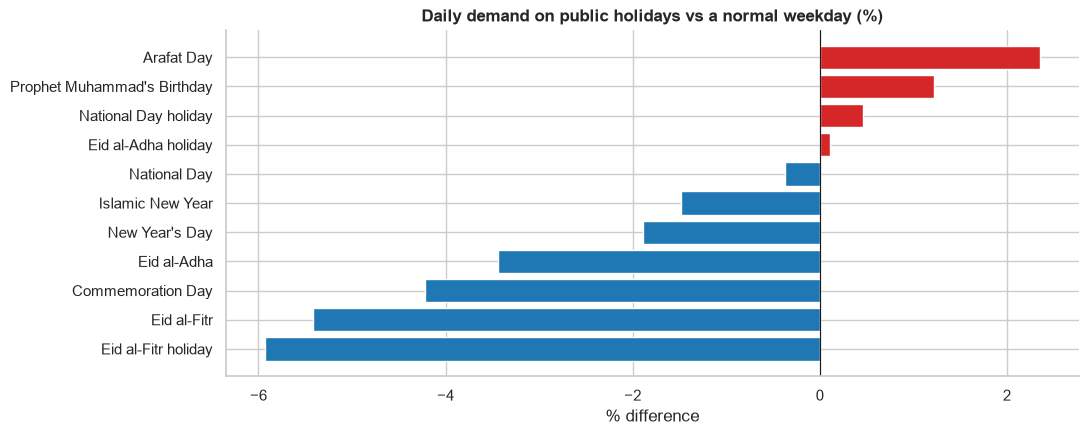

day before a holiday: +2.0 %   |   day after: +1.5 %


,mean,count,effect_%
holiday_name,,,
Eid al-Fitr holiday,0.936,10,-5.931
Eid al-Fitr,0.942,3,-5.414
Commemoration Day,0.953,2,-4.222
Eid al-Adha,0.961,3,-3.435
New Year's Day,0.977,3,-1.886
Islamic New Year,0.981,3,-1.479
National Day,0.992,2,-0.374
Eid al-Adha holiday,0.997,6,0.113
National Day holiday,1.000,2,0.464


In [34]:
hol = dd[dd.hol].join(calx.holiday_name)
by_hol = hol.groupby("holiday_name").rel.agg(["mean", "count"]).sort_values("mean")
by_hol["effect_%"] = (by_hol["mean"] / normal[normal.dow < 5].rel.mean() - 1) * 100
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.barh(by_hol.index, by_hol["effect_%"], color=np.where(by_hol["effect_%"] < 0, "tab:blue", "tab:red"))
ax.axvline(0, color="k", lw=0.8)
ax.set(title="Daily demand on public holidays vs a normal weekday (%)", xlabel="% difference")
plt.show()
before = dd[dd.hol.shift(-1, fill_value=False) & ~dd.hol].rel.mean()
after = dd[dd.hol.shift(1, fill_value=False) & ~dd.hol].rel.mean()
print(f"day before a holiday: {(before / normal.rel.mean() - 1) * 100:+.1f} %   |   day after: "
      f"{(after / normal.rel.mean() - 1) * 100:+.1f} %")
by_hol.round(3)

### 11.2 Ramadan - the day is reshaped

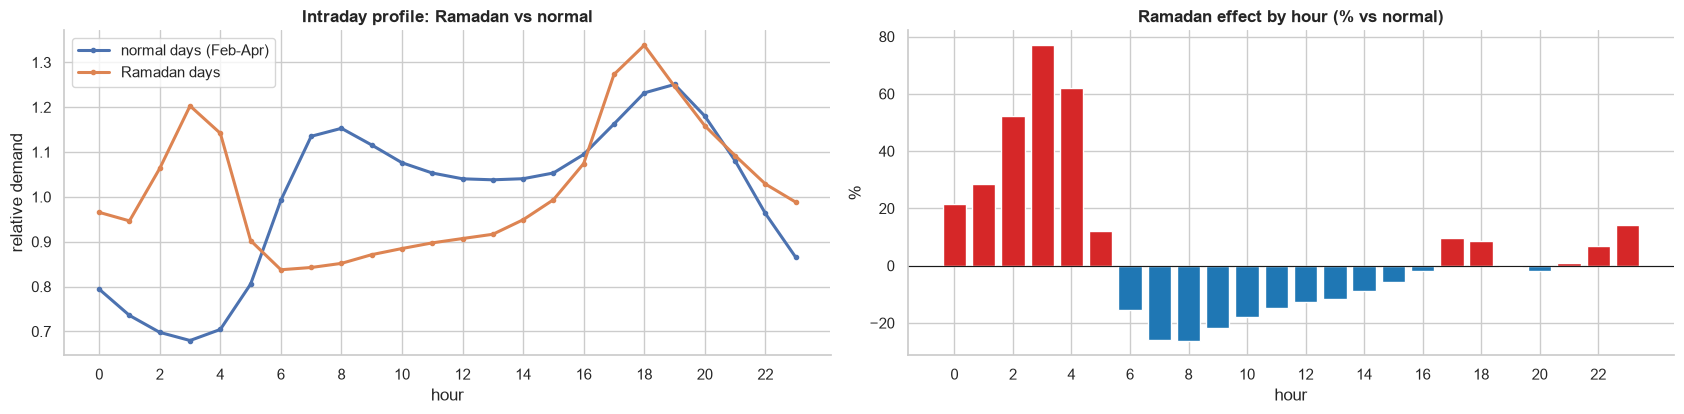

daily level: Ramadan 1.015 vs non-Ramadan 0.998 (+1.8 %)
pre-dawn (02-04h) relative demand by week of Ramadan: {1: 1.14, 2: 1.116, 3: 1.132, 4: 1.153, 5: 1.235}


In [35]:
spring = df.month.isin([2, 3, 4]) & ~df.is_public_holiday
r_prof = df[spring & df.is_ramadan].groupby("hour").rel.mean()
n_prof = df[spring & ~df.is_ramadan].groupby("hour").rel.mean()
diff = (r_prof / n_prof - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(17, 4.3))
axes[0].plot(n_prof.index, n_prof, lw=2.2, marker="o", ms=3, label="normal days (Feb-Apr)")
axes[0].plot(r_prof.index, r_prof, lw=2.2, marker="o", ms=3, label="Ramadan days")
axes[0].set(title="Intraday profile: Ramadan vs normal", xlabel="hour", ylabel="relative demand", xticks=range(0, 24, 2))
axes[0].legend()
axes[1].bar(diff.index, diff, color=np.where(diff > 0, "tab:red", "tab:blue"))
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set(title="Ramadan effect by hour (% vs normal)", xlabel="hour", ylabel="%", xticks=range(0, 24, 2))
plt.tight_layout(); plt.show()

rd = dd[dd.month.isin([2, 3, 4]) & ~dd.hol]
print(f"daily level: Ramadan {rd[rd.ram].rel.mean():.3f} vs non-Ramadan {rd[~rd.ram].rel.mean():.3f} "
      f"({(rd[rd.ram].rel.mean() / rd[~rd.ram].rel.mean() - 1) * 100:+.1f} %)")
wk = df[df.is_ramadan & ~df.is_public_holiday].assign(week=lambda d: (d.ramadan_day - 1) // 7 + 1)
print("pre-dawn (02-04h) relative demand by week of Ramadan:",
      wk[wk.hour.isin([2, 3, 4])].groupby("week").rel.mean().round(3).to_dict())

### 11.3 School summer break

In [36]:
summer = dd[dd.month.isin([6, 7, 8, 9]) & ~dd.hol]
print("Jun-Sep daily level, school break vs not:", summer.groupby("school").rel.mean().round(3).to_dict(),
      f"-> {(summer[summer.school].rel.mean() / summer[~summer.school].rel.mean() - 1) * 100:+.1f} %")

Jun-Sep daily level, school break vs not: {False: 1.007, True: 0.992} -> -1.4 %


> **Findings - calendar**
> * **Public holidays lower demand, with the Eids clearly the largest effect:** Eid al-Fitr about **−5 to −6 %**,
>   Commemoration Day about −4 %, Eid al-Adha about −3 %. Most one-day civic holidays are within ±2 % of a
>   normal day. Holiday profiles look like weekends (late, flat morning). **The day before and after a holiday
>   run 1-2 % higher** (travel and preparation). -> A single `is_holiday` flag averages away the Eid effect; a
>   **holiday-type feature** (Eid / other) is worth testing.
> * **Ramadan reshapes the day rather than the total:** the daily level is only about **+1.8 %**, but the hours
>   change completely - **pre-dawn (suhoor, 02-04h) +52 to +77 %**, **daytime (06-15h) −6 to −26 %**, a
>   **pre-iftar peak at 17-18h (+9 %)** and higher late-night use (22-01h, +7 to +29 %). The suhoor peak
>   **grows towards the end of the month** (relative 1.14 in week 1 → 1.24 in the last days), so `ramadan_day`
>   carries signal as well as `is_ramadan`. -> **A model needs a Ramadan × hour interaction.** Trees and neural
>   nets learn it from `is_ramadan` + `hour`; a linear model needs it built explicitly. Because Ramadan moves ~11
>   days earlier each year, `month`/`day-of-year` cannot stand in for it.
> * **School summer break: about −1.5 %** against the same months without the break.

## 12. Events

The calendar records three events. We look at each around its dates.

In [37]:
ev = cal[cal.event_type.notna()].copy()
ev["block"] = ((ev.event_name != ev.event_name.shift()) | (ev.date.diff().dt.days != 1)).cumsum()
events = ev.groupby("block").agg(event=("event_name", "first"), type=("event_type", "first"), start=("date", "min"),
                                 end=("date", "max"), days=("date", "count"), note=("event_note", "first"))
events

,event,type,start,end,days,note
block,,,,,,
1,April 2024 floods,weather,2024-04-15,2024-04-17,3,Record rainfall (~164 mm at DXB); network disr...
2,Post-flood recovery,operational,2024-04-18,2024-04-21,4,"Mains flushing, cleaning and refilling after t..."
3,New development online,structural,2025-07-01,2026-09-30,457,Phased handover of a large residential distric...


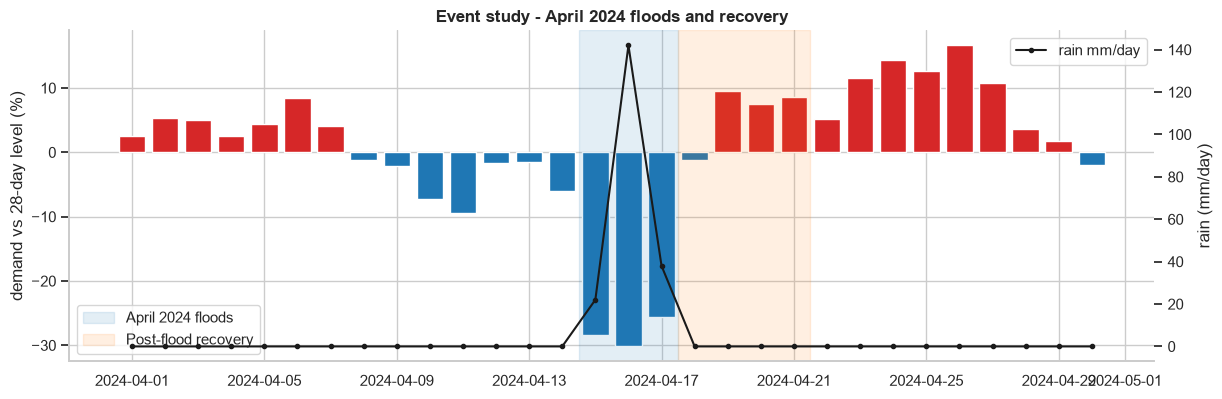

daily demand vs level during events: {'04-14': '-6%', '04-15': '-28%', '04-16': '-30%', '04-17': '-26%', '04-18': '-1%', '04-19': '+10%', '04-20': '+8%', '04-21': '+9%', '04-22': '+5%'}


In [38]:
win = dd["2024-04-01":"2024-04-30"]
fig, ax = plt.subplots(figsize=(14, 4.3))
ax.bar(win.index, (win.rel - 1) * 100, color=np.where(win.rel < 1, "tab:blue", "tab:red"))
ax2 = ax.twinx(); ax2.plot(win.index, win.rain, "k.-", label="rain mm/day"); ax2.set_ylabel("rain (mm/day)"); ax2.grid(False)
for _, e in events[events.type.isin(["weather", "operational"])].iterrows():
    ax.axvspan(e.start - pd.Timedelta(hours=12), e.end + pd.Timedelta(hours=12), alpha=0.12,
               color="tab:blue" if e.type == "weather" else "tab:orange", label=e.event)
ax.set(title="Event study - April 2024 floods and recovery", ylabel="demand vs 28-day level (%)")
ax.legend(loc="lower left"); ax2.legend(loc="upper right"); plt.show()
print("daily demand vs level during events:",
      {d.strftime("%m-%d"): f"{(v - 1) * 100:+.0f}%" for d, v in dd["2024-04-14":"2024-04-22"].rel.items()})

> **Findings - events**
> * **April 2024 floods (weather):** record rainfall (~164 mm) cut demand by **~26-30 %** for three days
>   (closures, working from home, network disruption). The **post-flood recovery (operational)** that followed
>   ran **+8 to +10 %** after its first day (mains flushing and refilling). Both are real, large and **very rare**: seven days in
>   2.75 years. A model cannot learn such effects from so few examples. In production they are better handled by
>   **operator overrides** than by features. In training they should be **flagged or excluded** so they do not
>   distort the normal-day fit.
> * **New development online (structural):** it is flagged on **every day from July 2025 onwards** (457 days). It
>   is not an event but a **regime indicator**. Its effect shows up as the accelerated growth in Section 4 and is
>   indistinguishable from the trend. -> As a feature it is simply a “time after July 2025” flag; a growth-aware
>   model does not need it.

## 13. Residual anomalies - which days are unusual even after known effects?

Days with the largest robust-STL remainder (daily series), annotated with the calendar. This checks whether the
known drivers explain the extreme days.

In [39]:
resid = (stl_d.resid / stl_d.trend * 100).rename("residual_%")
top = resid.abs().sort_values(ascending=False).head(15).index
anoms = pd.DataFrame({"residual_%": resid[top].round(1)}).join(
    calx[["day_of_week", "holiday_name", "is_ramadan", "event_name"]]).join(dd[["tmax", "rain"]].round(1))
anoms

,residual_%,day_of_week,holiday_name,is_ramadan,event_name,tmax,rain
timestamp_local,,,,,,,
2024-04-16,-31.4,Tuesday,None,False,April 2024 floods,28.3,142.0
2024-04-15,-25.2,Monday,None,False,April 2024 floods,27.0,22.0
2024-04-17,-23.7,Wednesday,None,False,April 2024 floods,31.6,38.0
2024-11-24,14.5,Sunday,None,False,None,38.0,0.0
2024-06-19,13.4,Wednesday,None,False,None,42.5,0.0
2024-11-15,-13.1,Friday,None,False,None,29.4,25.2
2024-07-27,13.0,Saturday,None,False,None,44.3,0.0
2026-01-10,-13.0,Saturday,None,False,New development online,28.4,0.0
2026-04-21,12.2,Tuesday,None,False,New development online,40.2,0.0


> **Findings - anomalies**
> * **Most extreme days have a known cause:** the **April 2024 floods** (−24 to −31 %), **heavy rain**
>   (2024-11-15, 25 mm, −13 %), an **Eid holiday** (2026-03-22, −12 %), and **heat spells** - summer days at
>   42-47 °C and an unusually hot late November 2024 (+11 to +15 %). These are exactly the drivers identified
>   above, which supports the feature set.
> * **A few are not explained by the data** (e.g. 2026-01-10, −13 % on an ordinary January Saturday). These are the
>   irreducible surprises any model will miss. Operationally, they are candidates for review with the network
>   operations team (unrecorded outages, operational changes).

## 14. Summary of findings

| # | Finding | Evidence | Modelling decision |
|---|---|---|---|
| 1 | Complete hourly grid; 0.32 % invalid readings | 60 nulls, 6 spikes, 1 negative, 9 frozen | Drop invalid hours from training; lags stay NaN |
| 2 | **Frozen meter not caught by the production gate** | 9 identical readings, all inside the valid range | -> add a consecutive-identical check to `quality.py` |
| 3 | **~10 %/yr growth**, accelerating after Jul 2025 | annual means 99.6k → 116.6k; YoY 5-6 % → 9-10 % | Normalise the target by a growth trend (tested in 02) |
| 4 | Daily cycle dominates | MSTL strength 0.97, peak/trough 1.9 | Hour features and Fourier terms; weekly lags |
| 5 | Weekly cycle weak; weekend = Sat-Sun | strength 0.57; Sat +4 %, Fri +2.5 % | Day-of-week features are enough |
| 6 | Annual cycle ±9 %, driven by temperature | Jan 0.92 → Jun 1.09 | Weather features, not month dummies, carry it |
| 7 | **Temperature hinge at ~24.4 °C, +1.4 %/°C** | piecewise fit; r = 0.86 | -> cooling threshold ~25 °C instead of 20 °C; heating term not needed |
| 8 | Weather forecast MAE ≈ 0.9 °C, unbiased | forecast vs observed | Train on the forecast (no skew); ~1 % irreducible error on hot days |
| 9 | **Ramadan reshapes intraday demand** | 02-04h +52-77 %, daytime −6-26 %, daily +1.8 % | Ramadan × hour interaction (trees and DL learn it; linear needs it explicitly) |
| 10 | Eids are the only large holiday effects | Eid al-Fitr −5-6 %, others ≈ 0 | Consider an Eid/holiday-type feature; day before/after |
| 11 | Floods −26-30 %, recovery +7-10 % | 7 days total | Too rare to learn: flag/exclude; operator override |
| 12 | “Structural” event = regime flag since Jul 2025 | 457 consecutive days | Redundant with a trend-aware model |
| 13 | **Lag 24 is informative but not available at issue time** | anomaly persistence 0.57 (1 d) vs 0.27 (2 d) | Keep min lag 48 h; quantify a midnight issue time in 02 |
| 14 | Calendar-only remainder ≈ 3.3 % | MSTL remainder std | Target for a good model: well below 3.3 % MAPE |

### Recommendations for review
1. **Data quality:** add a frozen-value (stuck meter) rule to the production quality gate.
2. **Features:** move the cooling-degree knot to ~25 °C; drop or keep (harmless) the heating-degree term; test an
   Eid / holiday-type feature and a recent observed-temperature feature (D−1 mean); flag the flood and recovery
   days as non-representative for training.
3. **Target:** make the model growth-aware - normalise by a trend fitted on the training history (validated in
   `02_modelling.ipynb`).
4. **Validation:** use rolling-origin backtests across a **full year**, so summer peaks, Ramadan and both Eids are
   in the test set. Report MAPE together with **peak-hour MAPE** and **bias**.
5. **Business decision - issue time:** the current morning issue rules out lag 24. `02_modelling.ipynb` quantifies
   what a midnight issue with real-time SCADA would gain.